# ДЗ: Кластеризация на эмбеддингах нейросети

## Цель
Сравнить кластеризацию изображений MNIST:
- по **сырым пикселям**;
- по **эмбеддингам**, извлечённым из предобученной **ResNet-18**.

## Что делается в работе
1. Загружается MNIST.
2. Строится baseline-кластеризация по исходным пикселям.
3. Из изображений извлекаются эмбеддинги ResNet-18.
4. На эмбеддингах запускаются те же алгоритмы кластеризации.
5. Сравниваются метрики:
   - **silhouette score** — внутренняя метрика;
   - **ARI** — внешняя метрика;
   - **NMI** — дополнительная внешняя метрика.
6. Строятся визуализации через **PCA** и **t-SNE**.

## Алгоритмы
- KMeans
- Agglomerative Clustering

## Дополнительно
- Сравнение с baseline по сырым пикселям
- Дополнительная метрика NMI
- Визуализация PCA и t-SNE

In [1]:
# ============================================================
# Импорты и воспроизводимость
# ============================================================

import os
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
import torchvision.transforms as T
from torchvision import models

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def set_seed(seed: int = 111):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 111
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Device: cuda


## Загрузка MNIST

В качестве датасета используется **MNIST** из практики по кластеризации.  
Истинные метки цифр используются **только для оценки качества кластеризации**, но не для обучения алгоритмов.

In [2]:
# ============================================================
# Загрузка датасета MNIST
# ============================================================

HF_CACHE_DIR = "./hf_cache"

dataset = load_dataset("mnist", cache_dir=HF_CACHE_DIR)
print(dataset)

ds_train = dataset["train"]

# Чтобы notebook работал быстрее, берём подвыборку train
N_TRAIN = 5000
ds_sample = ds_train.shuffle(seed=SEED).select(range(N_TRAIN))

print("Размер подвыборки:", len(ds_sample))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mnist/train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

mnist/test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})
Размер подвыборки: 5000


In [3]:
# ============================================================
# Подготовка матрицы сырых пикселей X и меток y_true
# ============================================================

X_list = []
y_true_list = []

for item in ds_sample:
    img = item["image"]
    label = item["label"]

    arr = np.array(img, dtype=np.float32)  # (28, 28)
    X_list.append(arr.reshape(-1))         # -> (784,)
    y_true_list.append(label)

X = np.stack(X_list, axis=0)
y_true = np.array(y_true_list)

print("Форма X:", X.shape)
print("Форма y_true:", y_true.shape)
print("Распределение меток:", Counter(y_true))

Форма X: (5000, 784)
Форма y_true: (5000,)
Распределение меток: Counter({np.int64(1): 550, np.int64(2): 534, np.int64(7): 516, np.int64(0): 506, np.int64(3): 502, np.int64(4): 488, np.int64(9): 485, np.int64(8): 481, np.int64(6): 478, np.int64(5): 460})


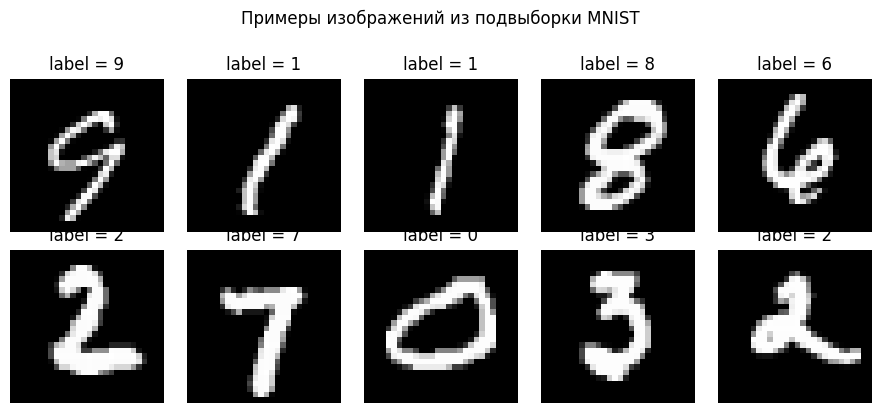

In [4]:
# ============================================================
# Визуальный просмотр нескольких изображений
# ============================================================

n_rows, n_cols = 2, 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.8 * n_cols, 2.0 * n_rows))
axes = axes.ravel()

for ax, item in zip(axes, ds_sample):
    img = np.array(item["image"], dtype=np.float32)
    label = item["label"]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"label = {label}")
    ax.axis("off")

plt.suptitle("Примеры изображений из подвыборки MNIST", y=1.02)
plt.tight_layout()
plt.show()

## Масштабирование признаков

Для baseline-кластеризации по сырым пикселям используем `StandardScaler`, как и в практике.

In [5]:
# ============================================================
# Масштабирование сырых пикселей
# ============================================================

scaler_raw = StandardScaler()
X_scaled = scaler_raw.fit_transform(X)

print("Форма X_scaled:", X_scaled.shape)

Форма X_scaled: (5000, 784)


In [6]:
# ============================================================
# Инфраструктура для метрик
# ============================================================

cluster_results = {}

def log_cluster_results(model_name, X_used, labels, y_true=None):
    metrics = {}

    unique_labels = np.unique(labels)
    metrics["n_clusters"] = len(unique_labels)

    if metrics["n_clusters"] > 1 and len(X_used) > metrics["n_clusters"]:
        metrics["silhouette"] = silhouette_score(X_used, labels)
    else:
        metrics["silhouette"] = np.nan

    if y_true is not None:
        metrics["ari"] = adjusted_rand_score(y_true, labels)
        metrics["nmi"] = normalized_mutual_info_score(y_true, labels)
    else:
        metrics["ari"] = np.nan
        metrics["nmi"] = np.nan

    cluster_results[model_name] = metrics
    return metrics

def results_to_dataframe(results):
    if not results:
        return pd.DataFrame()
    return pd.DataFrame.from_dict(results, orient="index").sort_index()

## Baseline: кластеризация по сырым пикселям

В качестве baseline используются два алгоритма:
- **KMeans**
- **Agglomerative Clustering (Ward)**

Они запускаются на исходных пиксельных признаках размерности **784**.

In [7]:
# ============================================================
# Baseline 1: KMeans на сырых пикселях
# ============================================================

kmeans_raw = KMeans(n_clusters=10, random_state=SEED, n_init="auto")
labels_kmeans_raw = kmeans_raw.fit_predict(X_scaled)

log_cluster_results("KMeans (raw pixels)", X_scaled, labels_kmeans_raw, y_true=y_true)
results_to_dataframe(cluster_results)

,n_clusters,silhouette,ari,nmi
KMeans (raw pixels),10,-0.01418,0.277135,0.408133


In [8]:
# ============================================================
# Baseline 2: Agglomerative на сырых пикселях
# ============================================================

agg_raw = AgglomerativeClustering(n_clusters=10, linkage="ward")
labels_agg_raw = agg_raw.fit_predict(X_scaled)

log_cluster_results("Agglomerative (raw pixels)", X_scaled, labels_agg_raw, y_true=y_true)
results_to_dataframe(cluster_results)

,n_clusters,silhouette,ari,nmi
Agglomerative (raw pixels),10,-0.044847,0.434544,0.567486
KMeans (raw pixels),10,-0.014180,0.277135,0.408133


**Короткий вывод по baseline.**  
Эти результаты служат отправной точкой. Далее сравниваем их с кластеризацией в пространстве признаков нейросети.

## Эмбеддинги ResNet-18

Теперь вместо сырых пикселей используются **эмбеддинги нейросети**.

Так как ResNet-18 ожидает:
- 3 канала,
- размер 224×224,
- нормализацию как у ImageNet,

изображения MNIST предварительно:
- масштабируются до 224×224;
- переводятся из grayscale в 3 канала;
- нормализуются стандартными `mean/std` ImageNet.

Финальный слой ResNet-18 удаляется, и сеть используется как **feature extractor**.  
В результате для каждого изображения получаем вектор признаков длины **512**.

In [9]:
# ============================================================
# Dataset-обёртка для ResNet-18
# ============================================================

class MNISTResNetDataset(Dataset):
    def __init__(self, ds):
        self.ds = ds
        self.transform = T.Compose([
            T.Resize((224, 224)),
            T.Grayscale(num_output_channels=3),
            T.ToTensor(),
            T.Normalize(
                mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)
            )
        ])

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        img = item["image"]
        label = item["label"]
        img = self.transform(img)
        return img, label

In [10]:
# ============================================================
# ResNet-18 как extractor признаков
# ============================================================

feat_net = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for p in feat_net.parameters():
    p.requires_grad = False

feat_net.fc = nn.Identity()
feat_net = feat_net.to(device).eval()

print("ResNet-18 готова для извлечения эмбеддингов.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


ResNet-18 готова для извлечения эмбеддингов.


In [11]:
# ============================================================
# Извлечение эмбеддингов
# ============================================================

dataset_resnet = MNISTResNetDataset(ds_sample)
loader_resnet = DataLoader(dataset_resnet, batch_size=128, shuffle=False, num_workers=0)

def extract_embeddings(loader, model, device):
    all_feats = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            z = model(xb)   # [B, 512]
            all_feats.append(z.cpu().numpy())
            all_labels.append(yb.numpy())

    X_emb = np.concatenate(all_feats, axis=0)
    y_emb = np.concatenate(all_labels, axis=0)
    return X_emb, y_emb

X_emb, y_emb = extract_embeddings(loader_resnet, feat_net, device)

print("Форма эмбеддингов:", X_emb.shape)
print("Форма меток:", y_emb.shape)

Форма эмбеддингов: (5000, 512)
Форма меток: (5000,)


In [12]:
# ============================================================
# Масштабирование эмбеддингов
# ============================================================

scaler_emb = StandardScaler()
X_emb_scaled = scaler_emb.fit_transform(X_emb)

print("Форма X_emb_scaled:", X_emb_scaled.shape)

Форма X_emb_scaled: (5000, 512)


## Кластеризация на эмбеддингах

Те же алгоритмы кластеризации запускаются на признаках ResNet-18.

In [13]:
# ============================================================
# KMeans на эмбеддингах
# ============================================================

kmeans_emb = KMeans(n_clusters=10, random_state=SEED, n_init="auto")
labels_kmeans_emb = kmeans_emb.fit_predict(X_emb_scaled)

log_cluster_results("KMeans (ResNet embeddings)", X_emb_scaled, labels_kmeans_emb, y_true=y_emb)
results_to_dataframe(cluster_results)

,n_clusters,silhouette,ari,nmi
Agglomerative (raw pixels),10,-0.044847,0.434544,0.567486
KMeans (ResNet embeddings),10,0.064468,0.460104,0.578159
KMeans (raw pixels),10,-0.014180,0.277135,0.408133


In [14]:
# ============================================================
# Agglomerative на эмбеддингах
# ============================================================

agg_emb = AgglomerativeClustering(n_clusters=10, linkage="ward")
labels_agg_emb = agg_emb.fit_predict(X_emb_scaled)

log_cluster_results("Agglomerative (ResNet embeddings)", X_emb_scaled, labels_agg_emb, y_true=y_emb)
results_to_dataframe(cluster_results)

,n_clusters,silhouette,ari,nmi
Agglomerative (ResNet embeddings),10,0.050115,0.574023,0.680943
Agglomerative (raw pixels),10,-0.044847,0.434544,0.567486
KMeans (ResNet embeddings),10,0.064468,0.460104,0.578159
KMeans (raw pixels),10,-0.014180,0.277135,0.408133


**Короткий комментарий.**  
Если ARI и silhouette на эмбеддингах выше, чем на сырых пикселях, значит нейросеть действительно построила более удобное пространство признаков для кластеризации.

## Визуализация через PCA

Чтобы увидеть структуру данных, построим PCA-проекции:
- для сырых пикселей;
- для ResNet-эмбеддингов.

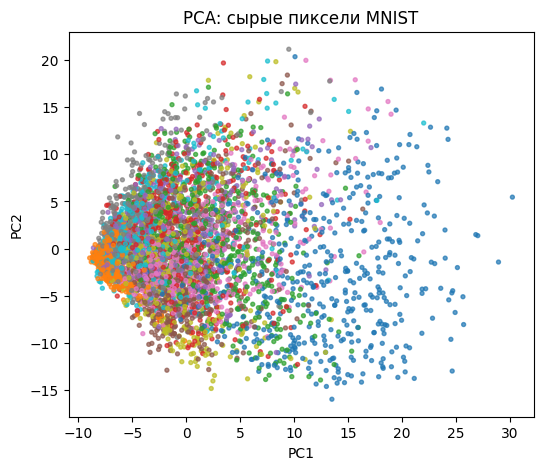

In [15]:
# ============================================================
# PCA для сырых пикселей
# ============================================================

pca_raw = PCA(n_components=2, random_state=SEED)
X_raw_2d = pca_raw.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_raw_2d[:, 0], X_raw_2d[:, 1], c=y_true, s=8, cmap="tab10", alpha=0.7)
plt.title("PCA: сырые пиксели MNIST")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

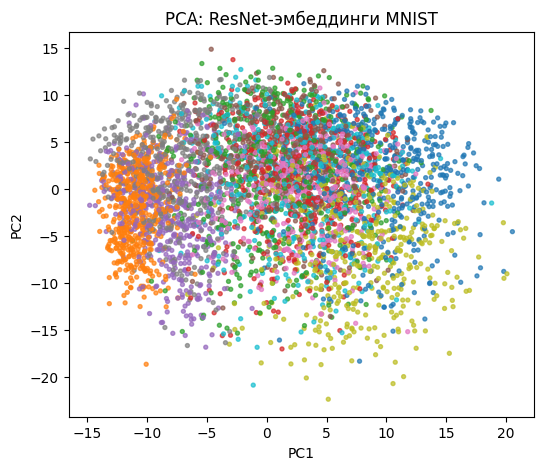

In [16]:
# ============================================================
# PCA для эмбеддингов
# ============================================================

pca_emb = PCA(n_components=2, random_state=SEED)
X_emb_2d = pca_emb.fit_transform(X_emb_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_emb_2d[:, 0], X_emb_2d[:, 1], c=y_emb, s=8, cmap="tab10", alpha=0.7)
plt.title("PCA: ResNet-эмбеддинги MNIST")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## t-SNE для эмбеддингов

`t-SNE` используется как дополнительная визуализация.  
Чтобы не перегружать notebook, строим её не на всей выборке, а на подмножестве объектов.

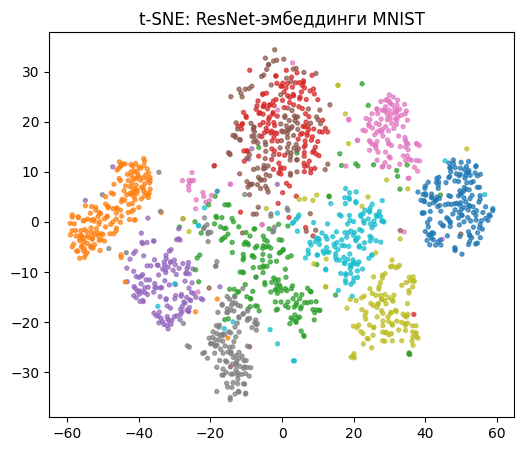

In [17]:
# ============================================================
# t-SNE для эмбеддингов
# ============================================================

TSNE_POINTS = min(1500, len(X_emb_scaled))
idx_tsne = np.random.choice(len(X_emb_scaled), TSNE_POINTS, replace=False)

X_tsne_sample = X_emb_scaled[idx_tsne]
y_tsne_sample = y_emb[idx_tsne]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=SEED,
)

X_emb_tsne = tsne.fit_transform(X_tsne_sample)

plt.figure(figsize=(6, 5))
plt.scatter(X_emb_tsne[:, 0], X_emb_tsne[:, 1], c=y_tsne_sample, s=8, cmap="tab10", alpha=0.7)
plt.title("t-SNE: ResNet-эмбеддинги MNIST")
plt.show()

## Итоговая таблица результатов

Сравниваются:
- baseline по сырым пикселям;
- кластеризация на эмбеддингах ResNet-18.

In [18]:
# ============================================================
# Итоговая таблица результатов
# ============================================================

df_results = results_to_dataframe(cluster_results).sort_values(by="ari", ascending=False)
df_results

,n_clusters,silhouette,ari,nmi
Agglomerative (ResNet embeddings),10,0.050115,0.574023,0.680943
KMeans (ResNet embeddings),10,0.064468,0.460104,0.578159
Agglomerative (raw pixels),10,-0.044847,0.434544,0.567486
KMeans (raw pixels),10,-0.014180,0.277135,0.408133


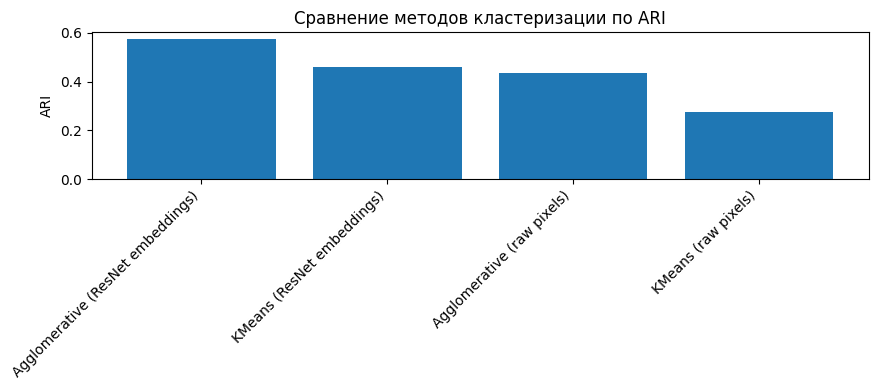

In [19]:
# ============================================================
# Барплот по ARI
# ============================================================

plt.figure(figsize=(9, 4))
plt.bar(df_results.index, df_results["ari"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("ARI")
plt.title("Сравнение методов кластеризации по ARI")
plt.tight_layout()
plt.show()

## Краткий анализ результатов

- **Silhouette** — внутренняя метрика, показывает, насколько кластеры компактны и отделены друг от друга.
- **ARI** — внешняя метрика, сравнивает кластеры с истинными метками цифр.
- **NMI** — дополнительная внешняя метрика, показывает согласие разбиения с настоящими классами.

Главный вопрос работы:  
**становится ли кластеризация лучше, если вместо сырых пикселей использовать эмбеддинги нейросети?**

# Итоговые выводы

В работе была выполнена кластеризация датасета **MNIST** по двум типам признаков:
- по **сырым пикселям** (784 признака);
- по **эмбеддингам**, извлечённым из предобученной **ResNet-18** (512 признаков).

Для кластеризации были использованы два алгоритма:
- **KMeans**;
- **Agglomerative Clustering**.

Качество кластеризации оценивалось по:
- внутренней метрике **silhouette score**;
- внешним метрикам **ARI** и **NMI**.

По итоговой таблице можно сравнить, насколько меняются метрики при переходе от сырых пикселей к нейросетевым эмбеддингам.

Если значения **ARI** и **silhouette** на эмбеддингах оказываются выше, это означает, что ResNet-18 строит более информативное пространство признаков, где объекты одного класса ближе друг к другу, а объекты разных классов — дальше.

Таким образом, использование **эмбеддингов нейросети** позволяет улучшить качество кластеризации по сравнению с работой по исходным пикселям, а лучшим методом оказывается тот, который показывает максимальный **ARI** в итоговой таблице.